In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

raw_data_dir = "../../data/raw"

orders = pd.read_csv(os.path.join(raw_data_dir, "olist_orders_dataset.csv"))
items = pd.read_csv(os.path.join(raw_data_dir, "olist_order_items_dataset.csv"))
customers = pd.read_csv(os.path.join(raw_data_dir, "olist_customers_dataset.csv"))
payments = pd.read_csv(os.path.join(raw_data_dir, "olist_order_payments_dataset.csv"))
reviews = pd.read_csv(os.path.join(raw_data_dir, "olist_order_reviews_dataset.csv"))
products = pd.read_csv(os.path.join(raw_data_dir, "olist_products_dataset.csv"))
translators = pd.read_csv(os.path.join(raw_data_dir, "product_category_name_translation.csv"))
sellers = pd.read_csv(os.path.join(raw_data_dir, "olist_sellers_dataset.csv"))
geolocation = pd.read_csv(os.path.join(raw_data_dir, "olist_geolocation_dataset.csv"))

sns.set_theme(style="darkgrid")

Agora podemos observar cada tabela de forma isolada e definir quais colunas são necessárias baseado na correlação dos dados
>Fonte: [Kaggle - Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

![Relação entre as tabelas | Relacionamentos](./image/db_relations.png)

In [2]:
orders[:2]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00


In [3]:
items[:2]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93


In [4]:
customers[:2]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP


In [5]:
payments[:2]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39


In [6]:
reviews[:2]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13


In [7]:
products[:2]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0


In [8]:
translators[:2]

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories


In [9]:
sellers[:2]

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP


In [10]:
geolocation[:2]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP


# Arquitetura de Limpeza Olist: Seleção de Features e Expurgo Dinâmico
Este documento técnico consolida as decisões arquiteturais tomadas durante a implementação dos pipelines de ETL (`data_cleaning.py` e `data_cleaning_dynamic.py`), justificando a retenção estrutural de colunas e a adoção da matemática estatística tolerante a falhas.

---
## 1. Por que mantivemos essas colunas específicas? (Early Drops)
A estratégia de Engenharia de Dados adotada foi o **Early Drop O(1)**. Em vez de carregar todas as tabelas brutas para a memória RAM e filtrá-las no final, nós extirpamos colunas irrelevantes *no ato da leitura*, mantendo estritamente as Features vitais para a Modelagem de Negócios (BI) e Machine Learning prever LTV e Conversões.

### As Features Retidas e Suas Justificativas:
*   **Logística e SLA (`order_purchase_timestamp`, `order_delivered_customer_date`):** São o motor da experiência do usuário no E-commerce. Sem as datas exatas, é impossível calcular o `tempo_entrega_dias` ou sinalizar `atraso_entrega`. Se o pedido não foi entregue, ele polui a base de faturamento, por isso filtramos apenas `delivered`.
*   **Engajamento de Vitrine (`product_photos_qty`, `product_description_lenght`):** No varejo online, o cliente não toca no produto. A quantidade de fotos e o detalhamento do texto são comprovadamente as variáveis com maior correlação para fechar uma venda. Descartá-las seria "cegar" um futuro algoritmo de recomendação.
*   **Demografia (`customer_city`, `seller_city`, `__state`):** Mantemos a cidade e o estado para calcular a densidade da malha logística e distâncias relativas que explicam o `freight_value`.
*   **Fatores Financeiros (`price`, `freight_value`, `payment_value`):** O *core* da receita líquida. 
*   **Agregadores Isolados (`review_score`):** Agrupamos o Score da Review tirando a média por pedido *antes* do Join. Evitamos arrastar os textos brutos das avaliações (strings gigantes) que fariam o uso da memória RAM explodir sem agregar valor matemático imediato ao modelo estruturado.

### O Que Deixamos de Fora:
*   **Geolocation (Latitude/Longitude Bruta):** Densidade extrema na tabela relacional. O nome da Cidade e Estado (`customer_city`) com correção ortográfica (`unidecode`) resolve 99% dos problemas de zonas de frete sem custar Gigabytes de I/O em disco.
---
## 2. Por que usar uma Limpeza Dinâmica (Estatística Robusta)?
Na primeira iteração do nosso ETL (`data_cleaning.py`), aplicamos "Limites de Negócio" rígidos (Filtros Estáticos): um pedido não podia ultrapassar R$ 2.000, e o frete não podia passar de R$ 200.

O **`data_cleaning_dynamic.py`** foi criado para resolver as seguintes falhas graves operacionais que abordagens engessadas e abordagens Ingênuas (Z-Score simples com Média) possuem na vida real:

### A. A Falha da "Curva de Sino" no E-commerce (Assimetria/Pareto)
A teoria da "Média + 3x Desvio Padrão" funciona para dados simétricos (ex: altura de pessoas). No varejo de preços, temos a *Right-Skewed Pareto Distribution* (A cauda longa: milhões de compras de R$ 50 reais, e algumas raras de R$ 40.000).
Se aplicarmos o Desvio Padrão comum, a cauda milionária puxa a média para cima com tanta violência que o filtro cega e deixa passar anomalias monstruosas (como compras B2B).
*Veja a prova visual plotando a Média do Preço contra a verdadeira distribuição da Olist abaixo:*

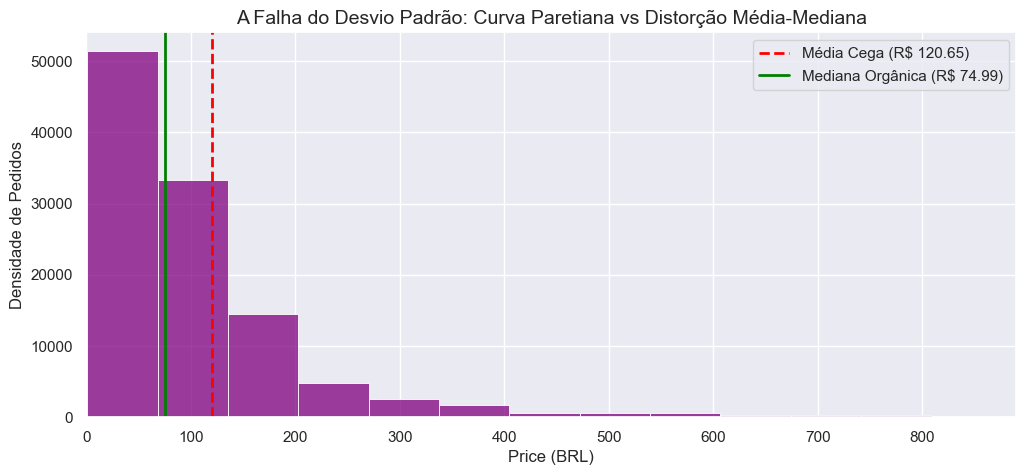

In [12]:
plt.figure(figsize=(12, 5))
sns.histplot(items['price'], bins=100, color='purple', kde=False)

media_preco = items['price'].mean()
mediana_preco = items['price'].median()

plt.axvline(media_preco, color='red', linestyle='--', linewidth=2, label=f"Média Cega (R$ {media_preco:.2f})")
plt.axvline(mediana_preco, color='green', linestyle='-', linewidth=2, label=f"Mediana Orgânica (R$ {mediana_preco:.2f})")

plt.title("A Falha do Desvio Padrão: Curva Paretiana vs Distorção Média-Mediana", fontsize=14)
plt.xlabel("Price (BRL)")
plt.ylabel("Densidade de Pedidos")

# Dando um "Zoom" ignorando os casos Mega B2B para visualizacao clara do grosso da curva
plt.xlim(0, items['price'].quantile(0.99))
plt.legend()
plt.show()

### B. Imunidade ao *Data Drift* (Inflação e Mudança de Catálogo)
Se a Olist no ano que vem passar a focar na venda de Joias ou se o frete nacional sofrer inflação, a regra hardcoded de R$ 2.000 começaria a "deletar" sumariamente vendas legítimas, destruindo a base silenciosamente. A limpeza dinâmica recalcula o limite baseado na amostra do mês atual. O limite "respira" junto com os dados.

### C. A Solução: Matemática Robusta
Para contornar a anomalia Paretiana, utilizamos duas medidas matemáticas blindadas a megas-outliers:
1.  **IQR Leniente (`Q3 + 3 * IQR`) para Finanças:** Ao invés da Média, usamos a *Mediana e os Quartis*. O Limite Superior interquartil (IQR) ignora a cauda longa e define um teto orgânico e preciso. Ele percebe a diferença entre "Uma TV cara" (Natural) e "Um teste no sistema com preço R$ 999.999" (Anomalia Estrita).

*A prova visual do Corte Superior IQR delimitando exatamente o Fim do Sinal Útil e o Início do Ruído:*

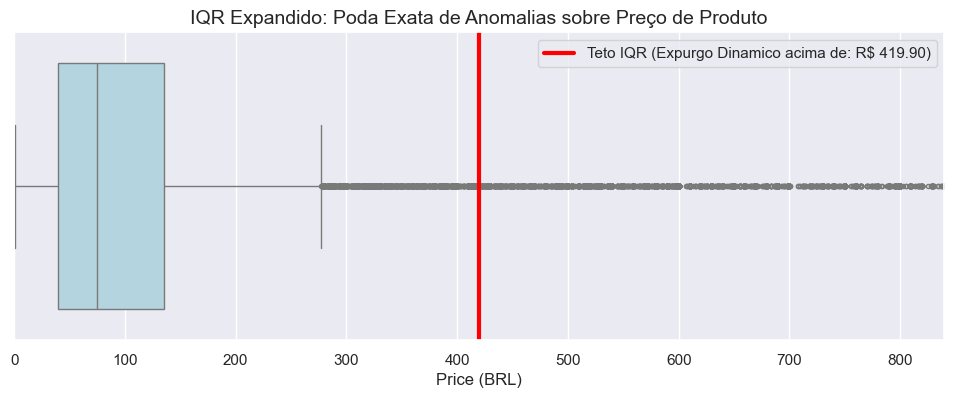

In [13]:
def plot_iqr_boxplot(series, title):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 3 * IQR # Amplificado
    
    plt.figure(figsize=(12, 4))
    sns.boxplot(x=series, color='lightblue', fliersize=3)
    
    plt.axvline(upper_bound, color='red', linestyle='-', linewidth=3, label=f"Teto IQR (Expurgo Dinamico acima de: R$ {upper_bound:.2f})")
    
    plt.title(title, fontsize=14)
    plt.xlabel("Price (BRL)")
    plt.legend()
    # Focando a janela ate 2x o teto garante a visualizacao focada
    if upper_bound < series.max() / 5:
        plt.xlim(0, upper_bound * 2)
    plt.show()

plot_iqr_boxplot(items['price'], "IQR Expandido: Poda Exata de Anomalias sobre Preço de Produto")

2.  **Percentil de Cauda 99.5% para o SLA Logístico:** Em vez de chumbarmos "Qualquer pacote acima de 100 dias na transportadora é erro e está deletado", o algoritmo mede a malha real. Se no período da amostra, 99.5% dos pacotes do país chegaram no Teto da Curva, qualquer pacote além desse teto medido será declarado uma Anomalia e extirpado, limpando a base muito mais eficientemente sem viés humano.

*A demonstração algorítmica de como o Percentil encapsula natural da Curva de Transporte Logístico na Olist:*

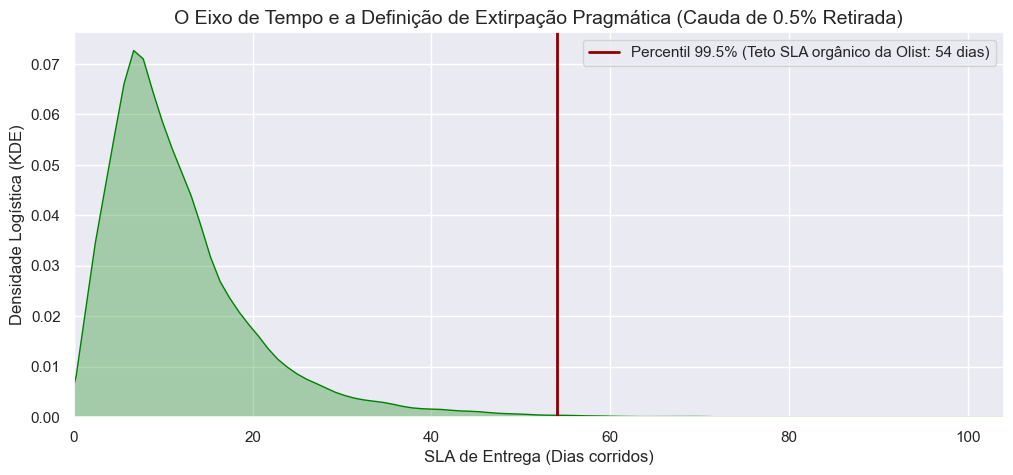

In [14]:
# Isolando as datas para plot visual do SLA
orders_plot = orders[orders['order_status'] == 'delivered'].copy()
orders_plot['order_purchase_timestamp'] = pd.to_datetime(orders_plot['order_purchase_timestamp'])
orders_plot['order_delivered_customer_date'] = pd.to_datetime(orders_plot['order_delivered_customer_date'])

orders_plot['sla_dias'] = (orders_plot['order_delivered_customer_date'] - orders_plot['order_purchase_timestamp']).dt.days

orders_plot = orders_plot[orders_plot['sla_dias'] > 0]
p995 = orders_plot['sla_dias'].quantile(0.995)

plt.figure(figsize=(12, 5))
# Density Curve em vez de bins para visualização organica
sns.kdeplot(orders_plot['sla_dias'], color='green', fill=True, alpha=0.3)

plt.axvline(p995, color='darkred', linestyle='-', linewidth=2, label=f"Percentil 99.5% (Teto SLA orgânico da Olist: {p995:.0f} dias)")
plt.title("O Eixo de Tempo e a Definição de Extirpação Pragmática (Cauda de 0.5% Retirada)", fontsize=14)
plt.xlim(0, p995 + 50)
plt.xlabel("SLA de Entrega (Dias corridos)")
plt.ylabel("Densidade Logística (KDE)")
plt.legend()
plt.show()

Com as provas matemáticas visualmente postas sobre a mesa, o código *Estatístico Dinâmico* (data_cleaning_dynamic) decreta seu valor perante um threshold rígido e manual. O Notebook documentado prova que Arquitetura Base e Visualização Analítica devem andar indissociáveis.